## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs.

You have several choices here:

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [1]:
import string
import os

### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [2]:
# if not os.path.exists('sonnets.txt'):
#     !wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks_basic/lab02_deep_learning/sonnets.txt

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()

TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START : TEXT_END]
assert len(text) == 2616

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [3]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here
text = [f.lower() for f in text]
text = ''.join(text).lower()

assert len(text) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')

OK!


In [4]:
text[:200]

"  from fairest creatures we desire increase,\n  that thereby beauty's rose might never die,\n  but as the riper should by time decease,\n  his tender heir might bear his memory:\n  but thou, contracted to"

Put all the characters, that you've seen in the text, into variable `tokens`.

In [5]:
tokens = sorted(set(text))

In [6]:
len(tokens)

38

Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [7]:
# dict <index>:<char>
# Your great code here
token_to_idx = {char: idx for idx, char in enumerate(tokens)}

# dict <char>:<index>
# Your great code here
idx_to_token = {idx: char for idx, char in enumerate(tokens)}

In [8]:
token_to_idx['b'], idx_to_token[13]

(13, 'b')

*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [9]:
# Your code here
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output
import random

In [37]:
# Citation: модифицированная имплементация с семинара курса Advanced ML цифровой кафедры
class CharRNNCell(torch.nn.Module):

    def __init__(self, num_tokens=len(tokens), embedding_size=15, rnn_num_units=1024):
        super(self.__class__,self).__init__()
        self.num_units = rnn_num_units
        self.embedding = torch.nn.Embedding(num_tokens, embedding_size)
        self.rnn_update = torch.nn.Linear(embedding_size + rnn_num_units, rnn_num_units)
        self.rnn_to_logits = torch.nn.Linear(rnn_num_units, num_tokens)

    def forward(self, x, h_prev):
        x_emb = self.embedding(x)
        x_and_h = torch.cat([x_emb, h_prev], dim=1)
        h_next = self.rnn_update(x_and_h)
        h_next = F.tanh(h_next)
        logits = self.rnn_to_logits(h_next)
        return h_next, logits

    def initial_state(self, batch_size):
        return torch.autograd.Variable(torch.zeros(batch_size, self.num_units))

In [38]:
def to_matrix(data, token_to_id, max_len=None, dtype='int32', batch_first = True):
    """Casts a list of names into rnn-digestable matrix"""

    max_len = max_len or max(map(len, data))
    data_ix = np.zeros([len(data), max_len], dtype) + token_to_id[' ']

    for i in range(len(data)):
        line_ix = [token_to_id[c] for c in data[i]]
        data_ix[i, :len(line_ix)] = line_ix

    if not batch_first: # convert [batch, time] into [time, batch]
        data_ix = np.transpose(data_ix)

    return data_ix

In [39]:
def rnn_loop(rnn, batch_index, device):
    """
    Computes log P(next_character) for all time-steps in names_ix
    :param names_ix: an int32 matrix of shape [batch, time], output of to_matrix(names)
    """
    batch_size, max_length = batch_index.size()
    hid_state = rnn.initial_state(batch_size).to(device)
    logprobs = []

    for x_t in batch_index.transpose(0,1):
        hid_state, logp_next = rnn(x_t, hid_state)
        logprobs.append(logp_next)

    return torch.stack(logprobs, dim=1)

In [40]:
def train(quotes, model, batch_size, optimizer, loss_func, num_epochs, device,
          token_to_idx, save_epoch=10, max_length=None):
  print("Start training...")

  num_tokens = len(token_to_idx)
  history = []
  for epoch in range(num_epochs):

    batch_index = to_matrix(random.sample(quotes, batch_size), token_to_idx,
                         max_len=max_length)
    batch_index = torch.tensor(batch_index, dtype=torch.int64).to(device)

    logp_seq = rnn_loop(model, batch_index, device=device)
    # print(logp_seq)

    # compute loss
    predictions_logp = logp_seq[:, :-1]
    actual_next_tokens = batch_index[:, 1:]

    # print(predictions_logp)
    # print(actual_next_tokens)

    # loss = -torch.mean(torch.gather(predictions_logp, dim=2, index=actual_next_tokens[:,:,None]))

    loss = loss_func(predictions_logp.reshape((-1, num_tokens)),
                     actual_next_tokens.reshape(-1)
                     )
    # train with backprop
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    # visualizing training process
    loss_value = loss.cpu().data.numpy()
    print("Epoch {} / {}. Loss: {}".format(epoch, num_epochs, loss_value))
    history.append(loss_value)
    if (epoch + 1) % save_epoch == 0:
        plt.figure()
        clear_output(True)
        plt.plot(history, label='loss')
        plt.legend()
        plt.show()

    if (epoch + 1) % save_epoch == 0:
      if loss_value < history[-2]:
        out_fname = "char_rnn_best.pth"
        with open(out_fname, "wb") as fp:
          torch.save(model.state_dict(), fp)

  return history

In [41]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # Use cuda:0 as default GPU
print(f"Using device: {device}") # Print the device being used

Using device: cuda:0


In [42]:
char_rnn = CharRNNCell().to(device)
optimizer = torch.optim.Adam(char_rnn.parameters())
loss_func = torch.nn.CrossEntropyLoss()

Plot the loss function (axis X: number of epochs, axis Y: loss function).

In [ ]:
# Your plot code here

In [43]:
import re

In [44]:
quotes = re.split('\n\n\s*[a-z]*\n\n', text)
quotes[:2]

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-115661265.py:1: SyntaxWarning: invalid escape sequence '\s'
  quotes = re.split('\n\n\s*[a-z]*\n\n', text)


["  from fairest creatures we desire increase,\n  that thereby beauty's rose might never die,\n  but as the riper should by time decease,\n  his tender heir might bear his memory:\n  but thou, contracted to thine own bright eyes,\n  feed'st thy light's flame with self-substantial fuel,\n  making a famine where abundance lies,\n  thy self thy foe, to thy sweet self too cruel:\n  thou that art now the world's fresh ornament,\n  and only herald to the gaudy spring,\n  within thine own bud buriest thy content,\n  and tender churl mak'st waste in niggarding:\n    pity the world, or else this glutton be,\n    to eat the world's due, by the grave and thee.",
 "  when forty winters shall besiege thy brow,\n  and dig deep trenches in thy beauty's field,\n  thy youth's proud livery so gazed on now,\n  will be a tatter'd weed of small worth held:\n  then being asked, where all thy beauty lies,\n  where all the treasure of thy lusty days;\n  to say, within thine own deep sunken eyes,\n  were an al

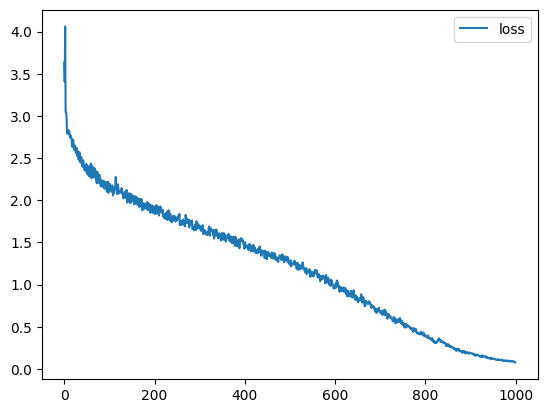

In [45]:
history = train(quotes=quotes,
                model=char_rnn,
                batch_size=32,
                optimizer=optimizer,
                loss_func=loss_func,
                max_length=None,
                device=device,
                num_epochs=1000,
                save_epoch=10,
                token_to_idx=token_to_idx)

In [72]:
MAX_LENGTH = 500
def generate_sample(char_rnn, seed_phrase=' Hello', max_length=MAX_LENGTH, temperature=1.0, device="cpu"):
    '''
    ### Disclaimer: this is an example function for text generation.
    ### You can either adapt it in your code or create your own function

    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
        smaller temperature converges to the single most likely output.

    Be careful with the model output. This model waits logits (not probabilities/log-probabilities)
    of the next symbol.
    '''

    char_rnn.to(device)
    x_sequence = [token_to_idx[token] for token in seed_phrase.lower()]
    # x_sequence = torch.tensor([[x_sequence]], dtype=torch.int64)
    x_sequence = torch.tensor([x_sequence], dtype=torch.int64)
    hid_state = char_rnn.initial_state(batch_size=1)


    #feed the seed phrase, if any
    for i in range(len(seed_phrase) - 1):
        # print(x_sequence[:, -1].shape, hid_state.shape)
        # out, hid_state = char_rnn(x_sequence[:, i], hid_state)
        hid_state, _ = char_rnn(x_sequence[:, i].to(device), hid_state)


    #start generating
    for _ in range(max_length - len(seed_phrase)):
        # print(x_sequence.shape, x_sequence, hid_state.shape)
        # out, hid_state = char_rnn(x_sequence[:, -1], hid_state)
        hid_state, out = char_rnn(x_sequence[:, -1].to(device), hid_state)

        # Be really careful here with the model output
        p_next = F.softmax(out / temperature, dim=-1).data.numpy()[0]

        # sample next token and push it back into x_sequence
        # print(p_next.shape, len(tokens))
        next_ix = np.random.choice(len(tokens), p=p_next)
        next_ix = torch.tensor([[next_ix]], dtype=torch.int64)
        # print(x_sequence.shape, next_ix.shape)
        x_sequence = torch.cat([x_sequence, next_ix], dim=1)

    return ''.join([tokens[ix] for ix in x_sequence.data.numpy()[0]])

In [53]:
# An example of generated text.
# print(generate_text(length=500, temperature=0.2))

In [64]:
device

device(type='cuda', index=0)

In [73]:
print(generate_sample(char_rnn=char_rnn, max_length=500, temperature=0.2, device="cpu"))

 hellowingry in thy beauty thee that weadon is ow shange shest live thre fair thee of your fears, nirft my neale soor that beauty which yot wond yitg
  the seatour might u heath will port af bath dading nove of youth in every thing,
  that heavy saturn laugh'd and leap'd with him,
  with ain these proul  mo thence thou terakest blough that with mein where;
  and the wirn for my wase, be ne bentle dase sweit ly sad,
  't of chorsed with make on me so,
  bet ai thiupprays of i forght
  with and to


In [85]:
TEMPERATURE_LIST = [0.1, 0.2, 0.5, 1.0, 2.0]

In [86]:
for t in TEMPERATURE_LIST:
    print(f"------------------Temprature {t}-------------------------------")
    print(generate_sample(char_rnn, max_length=500, temperature=t, device="cpu"))
    print("-------------------------------------------------------")

------------------Temprature 0.1-------------------------------
 hellowingrome cilv'd chesksh the tipertentige on the wind,
  in sight make them allly grawe shillst mast ey sisgl'sive:
  thou my self am bland,
  and hualt enlo sterl.
    o! not i fare evtor anday to her hiod apred:
    bet ay you  who doth her earended on shearse aistulen saye
  that behied thur in anwiol flore,
  and though my velsest from the the gear,
  wherein i poon buth thoreb
  toon ur the leabre as the tied,
  whilst i have swents of me.
  i me for the beauty of your graces fol whith
-------------------------------------------------------
------------------Temprature 0.2-------------------------------
 hellor'd what they sec;
  in pover see anowhe to be not so?
  if others  lotd, and for thy self thy sweet self dost deceive:
  then how when nature calls thee to be gone,
  what acceptable audit canst thou leave?
    thy unused beauty must be tombed with thee,
    which thee live your pent
    be, for no langel u

### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [78]:
from torch import nn

In [87]:
# Your beautiful code here
class CharRNNLoop(nn.Module):
    def __init__(self, num_tokens=len(tokens), emb_size=64, rnn_num_units=256):
        super(self.__class__, self).__init__()
        self.num_units=rnn_num_units

        self.emb = nn.Embedding(num_tokens, emb_size)
        self.rnn = nn.LSTM(emb_size, rnn_num_units, batch_first=True)
        self.hid_to_logits = nn.Linear(rnn_num_units, num_tokens)

    def forward(self, x, state):
        out, state = self.rnn(self.emb(x), state)
        next_logits = self.hid_to_logits(out)
        next_logp = F.log_softmax(next_logits, dim=-1)
        return next_logp, state

    def initial_state(self, batch_size):
        return (torch.zeros(batch_size, self.num_units, requires_grad=True)[None, :, :].to(device),
                torch.zeros(batch_size, self.num_units, requires_grad=True)[None, :, :].to(device)
               )

In [88]:
class LSTMCell(torch.nn.Module):

    def __init__(self, num_tokens, embedding_size=64, lstm_num_units=256):
        super(self.__class__,self).__init__()
        self.num_units = lstm_num_units

        self.embedding = torch.nn.Embedding(num_tokens, embedding_size)
        self.fc1 = torch.nn.Linear(embedding_size + lstm_num_units, lstm_num_units)
        self.fc2 = torch.nn.Linear(embedding_size + lstm_num_units, lstm_num_units)
        self.fc3 = torch.nn.Linear(embedding_size + lstm_num_units, lstm_num_units)
        self.fc4 = torch.nn.Linear(embedding_size + lstm_num_units, lstm_num_units)

        self.lstm_to_logits = torch.nn.Linear(lstm_num_units, num_tokens)

    def forward(self, x, h_prev,c_prev):
        x_emb = self.embedding(x)
        x_and_h = torch.cat([x_emb, h_prev], dim=1)
        f=F.sigmoid(self.fc1(x_and_h))
        i=F.sigmoid(self.fc2(x_and_h))
        c=F.tanh(self.fc3(x_and_h))
        o=F.sigmoid(self.fc4(x_and_h))
        c_next = c_prev*f+i*c
        h_next = F.tanh(c_next)*o
        logits = self.lstm_to_logits(h_next)

        logits = self.lstm_to_logits(h_next)

        return h_next, c_next, F.log_softmax(logits, -1)

    def initial_state(self, batch_size):
        return torch.autograd.Variable(torch.zeros(batch_size, self.num_units,dtype=torch.float32)), torch.autograd.Variable(torch.zeros(batch_size, self.num_units,dtype=torch.float32))

In [89]:
def lstm_loop(lstm, batch_index, device):
    """
    :param names_ix: an int32 matrix of shape [batch, time], output of to_matrix(names)
    """
    batch_size, max_length = batch_index.size()
    hid_state, cell_state = lstm.initial_state(batch_size)
    hid_state=hid_state.to(device)
    cell_state=cell_state.to(device)
    logprobs = []

    for x_t in batch_index.transpose(0,1):
        hid_state, cell_state, logp_next = lstm(x_t, hid_state, cell_state)
        logprobs.append(logp_next)

    return torch.stack(logprobs, dim=1)

In [90]:
char_lstm = LSTMCell(num_tokens=len(token_to_idx))
char_lstm.to(device)
optimizer = torch.optim.Adam(char_lstm.parameters())

In [91]:
def train2(quotes, model, batch_size, optimizer, num_epochs, device,
          token_to_idx, save_epoch=10, max_length=None):
  print("Start training...")

  num_tokens = len(token_to_idx)
  history = []
  for epoch in range(num_epochs):

    batch_ix = to_matrix(random.sample(quotes, batch_size),
                         token_to_idx, max_len=max_length)
    batch_ix = torch.tensor(batch_ix, dtype=torch.int64).to(device)

    logp_seq = lstm_loop(model, batch_ix, device=device)

    # compute loss
    predictions_logp = logp_seq[:, :-1]
    actual_next_tokens = batch_ix[:, 1:]

    loss = -torch.mean(torch.gather(predictions_logp, dim=2,
                                    index=actual_next_tokens[:,:,None]))

    # train with backprop
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    # visualizing training process
    loss_value = loss.cpu().data.numpy()
    print("Epoch {} / {}. Loss: {}".format(epoch, num_epochs, loss_value))
    history.append(loss_value)
    if (epoch + 1) % save_epoch == 0:
        plt.figure()
        clear_output(True)
        plt.plot(history, label='loss')
        plt.legend()
        plt.show()

    if (epoch + 1) % save_epoch == 0:
      if loss_value < history[-2]:
        out_fname = "char_lstm_best.pth"
        with open(out_fname, "wb") as fp:
          torch.save(model.state_dict(), fp)

  return history

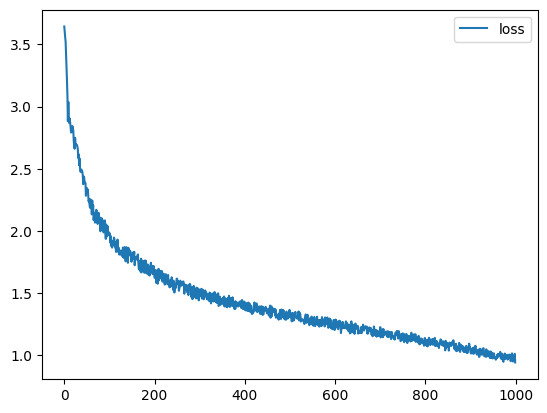

In [92]:
history2 = train2(quotes=quotes,
                  model=char_lstm,
                  batch_size=32,
                  optimizer=optimizer,
                  max_length=None,
                  device=device,
                  num_epochs=1000,
                  save_epoch=10,
                  token_to_idx=token_to_idx)

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

In [ ]:
# Text generation with different temperature values here

In [98]:
MAX_LENGTH = 500
def generate_sample2(char_lstm, seed_phrase=' Hello', max_length=MAX_LENGTH, temperature=1.0, device="cpu"):

    char_lstm.to(device)

    x_sequence = [token_to_idx[token] for token in seed_phrase.lower()]
    x_sequence = torch.tensor([x_sequence], dtype=torch.int64)
    hid_state, cell_state = char_lstm.initial_state(batch_size=1)
    hid_state=hid_state.to(device)
    cell_state=cell_state.to(device)

    for i in range(len(seed_phrase) - 1):
        hid_state,cell_state, _ = char_lstm(x_sequence[:, i].to(device), hid_state, cell_state)


    for _ in range(max_length - len(seed_phrase)):
        hid_state, cell_state,logp_next = char_lstm(x_sequence[:, -1].to(device), hid_state, cell_state)
        p_next = F.softmax(logp_next / temperature, dim=-1).cpu().data.numpy()[0]


        next_ix = np.random.choice(len(tokens), p=p_next)
        next_ix = torch.tensor([[next_ix]], dtype=torch.int64)
        x_sequence = torch.cat([x_sequence, next_ix], dim=1)

    return ''.join([tokens[ix] for ix in x_sequence.cpu().data.numpy()[0]])

In [99]:
for t in TEMPERATURE_LIST:
    print(f"------------------Temprature {t}-------------------------------")
    print(generate_sample2(char_lstm, max_length=500, temperature=t, device="cpu"))
    print("-------------------------------------------------------")

------------------Temprature 0.1-------------------------------
 hellown thee i have sweet from thee,
  and the world will be the world will of thy grace.
    if thou wilt should be thy self i love dearent.
  that i have sweet from the fairest and me.                                                                                                                                                                                                                                                                                                                         
-------------------------------------------------------
------------------Temprature 0.2-------------------------------
 hellown thee i have sweet doth dide,
  which i love that which i will be for my sight,
  and the praise the world will of this spire,
  when i have seen the painter than thou art,
  where thou art the confounded to the stand
  the praise the dear prove thee to the wears
  the outward form a face should be forth,


Выводы:

1) LSTM обучается медленнее, чем RNN.
2) LSTM генерирует лучше, чем RNN.
3) У обеих при средней температуре из списка (0.2-0.5) получается что-то более-менее приемлемое. При высокой (которая должна давать большую креативность) начинают появляться несуществующие слова, либо получается вообще каша (при 2.0).

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [100]:
# Saving and loading code here
out_fname = "saved_model.pth"
with open(out_fname, "wb") as fp:
  torch.save(char_lstm.state_dict(), fp)

### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a>
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch`)